Loading the Libraries and Dataset

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv('IPL_2022_dataset.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


BASIC INFORMATION

Check the size of row and columns of the dataset

In [44]:
df.shape

(74, 20)

How many columns have the null value in total?

In [45]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

SOME BASIC QUESTIONS

Which team won the most matches ?

<Axes: ylabel='match_winner'>

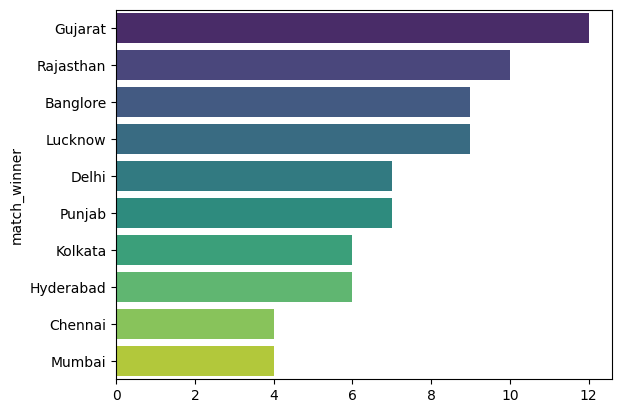

In [46]:
match_win=df['match_winner'].value_counts()
sns.barplot(y=match_win.index,x=match_win.values,palette='viridis')



Toss decision Trends?

<Axes: xlabel='toss_decision', ylabel='count'>

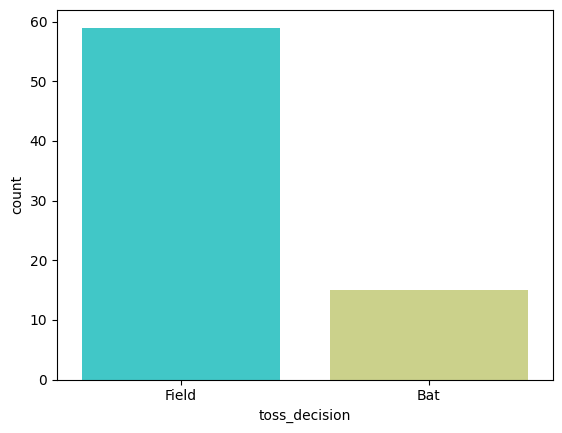

In [47]:
# toss_dec=df["toss_decision"].value_counts()
# sns.barplot(x=toss_dec.index,y=toss_dec.values,palette='rainbow')
sns.countplot(x=df['toss_decision'],palette='rainbow')

Toss winner v/s Match winner

In [48]:
(((df[df['toss_winner']==df['match_winner']]['match_id'].count())/len(df))*100).round(2)

np.float64(48.65)

How do team wins(Runs v/s Wicket)

<Axes: xlabel='won_by', ylabel='count'>

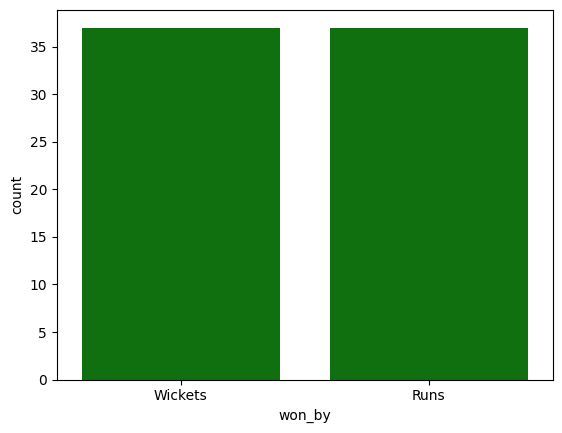

In [52]:
#win_type=df['won_by'].value_counts()
sns.countplot(x=df['won_by'],color='green')

Won most Player of the match award?

<Axes: ylabel='player_of_the_match'>

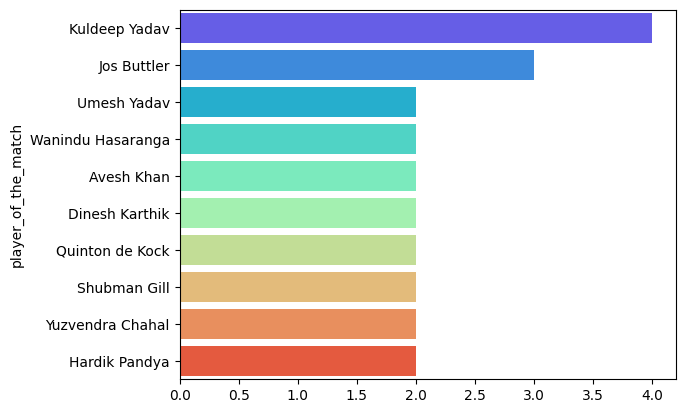

In [56]:
pom=df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=pom.index,x=pom.values,palette='rainbow')

Top two scorer?

<Axes: ylabel='top_scorer'>

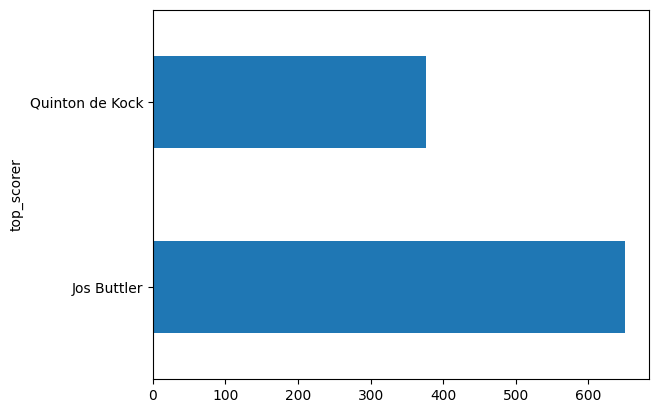

In [63]:
top_score=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
top_score.plot(kind='barh')

Top ten bowling Figure

<Axes: ylabel='best_bowling'>

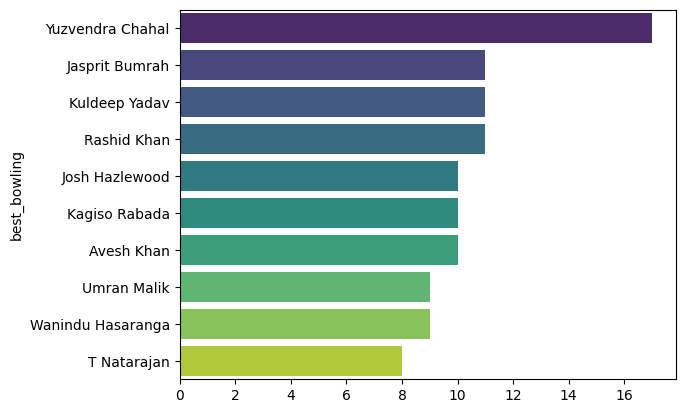

In [68]:
df['highest_wicket']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wicket']=df['highest_wicket'].astype(int)
best_bowling=df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=best_bowling.values,y=best_bowling.index,palette='viridis')

Most matches played by venue?

<Axes: ylabel='venue'>

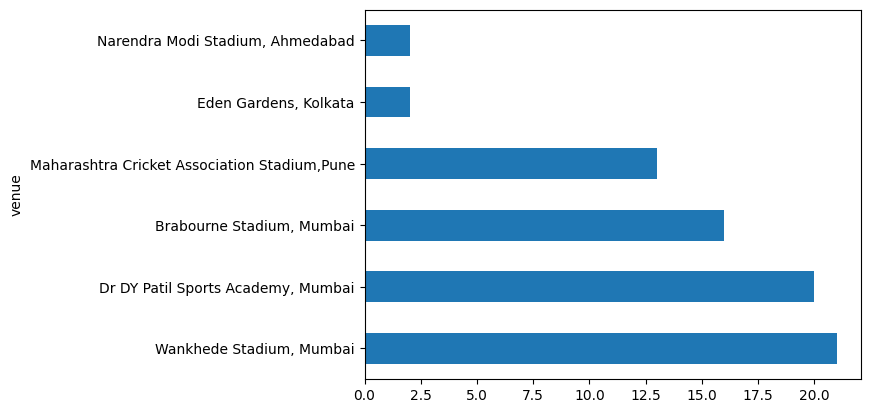

In [ ]:
venue_count=df['venue'].value_counts()
venue_count.plot(kind='barh')

Who won the highest margin by run ?


<Axes: ylabel='match_winner'>

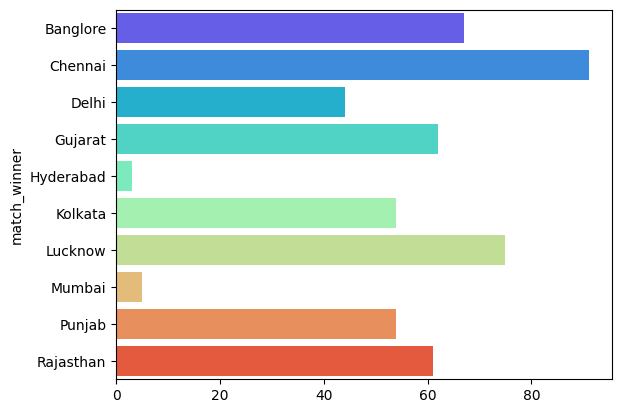

In [77]:
won_by_run=df[df['won_by']=='Runs']
highest_margin=won_by_run.groupby('match_winner')['margin'].max()
sns.barplot(x=highest_margin.values,y=highest_margin.index,palette='rainbow')

Which player  have highest individual score?

In [83]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which bowler had the best bowling figure ?

In [87]:
df[df['highest_wicket']==df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
